<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>RNN From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
Writing the RNN loop and its backprop through time in numpy, then training it to predict the next value of a signal. No framework, so every gradient is visible.
</div>

## the task

take a wave, cut it into windows of 20 values, and from those 20 predict the 21st. so the input is a sequence and the output is one number.

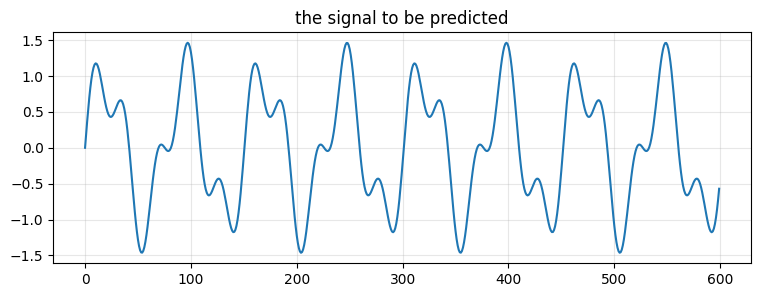

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 50, 600)
series = np.sin(t) + 0.5 * np.sin(2.5 * t)     # two waves added, not a plain sine

plt.figure(figsize=(9,3))
plt.plot(series)
plt.title('the signal to be predicted')
plt.grid(alpha=.3)
plt.show()

In [3]:
T = 20      # window length

def make_windows(s, T):
    X = np.array([s[i:i+T]   for i in range(len(s) - T)])
    Y = np.array([s[i+T]     for i in range(len(s) - T)])
    return X, Y

X, Y = make_windows(series, T)
print("X :", X.shape, " Y :", Y.shape)
print("first window :", np.round(X[0][:5], 3), "...  target :", round(Y[0], 3))

X : (580, 20)  Y : (580,)
first window : [0.    0.187 0.369 0.541 0.698] ...  target : 0.566


keeping the last 100 windows aside for testing, the model never sees them while training.

In [5]:
X_train, Y_train = X[:-100], Y[:-100]
X_test,  Y_test  = X[-100:], Y[-100:]
print(X_train.shape, X_test.shape)

(480, 20) (100, 20)


## forward pass

`h` starts at zero and gets updated 20 times, once per value in the window. the prediction is taken from the last hidden state only.

all the hidden states are stored while going forward, because BPTT needs them again on the way back.

In [6]:
def init(H, seed=0):
    rng = np.random.default_rng(seed)
    Wx = rng.normal(0, 0.3, (1, H))
    Wh = rng.normal(0, 0.3, (H, H)) * 0.5
    b  = np.zeros(H)
    Wy = rng.normal(0, 0.3, (H, 1))
    by = np.zeros(1)
    return Wx, Wh, b, Wy, by

def forward(X, Wx, Wh, b, Wy, by):
    n, T = X.shape
    h = np.zeros((n, Wx.shape[1]))
    states = [h]                       # h0, needed later
    for k in range(T):
        h = np.tanh(X[:, k:k+1] @ Wx + h @ Wh + b)
        states.append(h)
    pred = (h @ Wy + by).ravel()       # only the last state is used
    return pred, states

## backprop through time

the gradient enters at the last step and then travels backwards through the chain. at every step it passes through the tanh derivative `(1 - h^2)` and through Wh.

Wx, Wh and b are shared by all 20 steps, so their gradients are **added up** over all the steps instead of being seperate.

In [18]:
def backward(X, Y, pred, states, Wh, Wy):
    n, T = X.shape
    err = pred - Y
    d_out = 2 * err[:, None] / n            # d(mse)/d(pred)

    dWy = states[-1].T @ d_out
    dby = d_out.sum(axis=0)

    dh = d_out @ Wy.T                       # gradient going into the last hidden state
    dWx = np.zeros((1, Wh.shape[0]))
    dWh = np.zeros_like(Wh)
    db  = np.zeros(Wh.shape[0])

    for k in reversed(range(T)):
        dz = dh * (1 - states[k+1] ** 2)    # through the tanh
        dWx += X[:, k:k+1].T @ dz           # same weights every step, so gradients add up
        dWh += states[k].T @ dz
        db  += dz.sum(axis=0)
        dh   = dz @ Wh.T                    # one step further back in time

    return dWx, dWh, db, dWy, dby

gradients are clipped because in an RNN they can explode when they get multiplied by Wh again and again.

In [10]:
def train(X, Y, H=32, epochs=1500, lr=0.005, seed=0):
    Wx, Wh, b, Wy, by = init(H, seed)
    hist = []

    for ep in range(epochs + 1):
        pred, states = forward(X, Wx, Wh, b, Wy, by)
        loss = ((pred - Y) ** 2).mean()
        hist.append(loss)

        gWx, gWh, gb, gWy, gby = backward(X, Y, pred, states, Wh, Wy)
        for g in (gWx, gWh, gb, gWy, gby):
            np.clip(g, -1, 1, out=g)        # stops the gradient from exploding

        Wx -= lr * gWx
        Wh -= lr * gWh
        b  -= lr * gb
        Wy -= lr * gWy
        by -= lr * gby

        if ep % 250 == 0:
            print("epoch", str(ep).rjust(4), " loss", round(loss, 5))

    return (Wx, Wh, b, Wy, by), hist

In [11]:
params, hist = train(X_train, Y_train)
Wx, Wh, b, Wy, by = params

epoch    0  loss 2.52952


epoch  250  loss 0.01007


epoch  500  loss 0.00557


epoch  750  loss 0.00378


epoch 1000  loss 0.00279


epoch 1250  loss 0.00215


epoch 1500  loss 0.00173


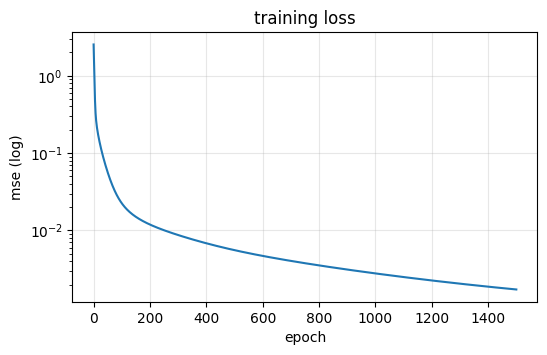

In [12]:
plt.figure(figsize=(6,3.5))
plt.plot(hist)
plt.yscale('log')
plt.xlabel('epoch'); plt.ylabel('mse (log)')
plt.title('training loss')
plt.grid(alpha=.3)
plt.show()

## how good is it on the unseen part

In [13]:
test_pred, _ = forward(X_test, Wx, Wh, b, Wy, by)
test_mse = ((test_pred - Y_test) ** 2).mean()

# baseline, just repeat the last value of the window
baseline = ((X_test[:, -1] - Y_test) ** 2).mean()

print("rnn test mse      :", round(test_mse, 5))
print("baseline test mse :", round(baseline, 5))

rnn test mse      : 0.0021
baseline test mse : 0.00781


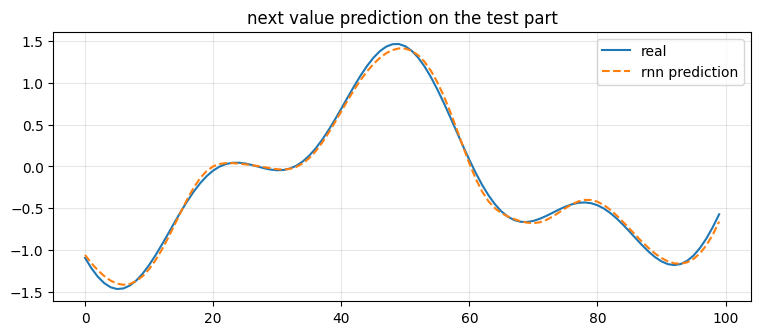

In [14]:
plt.figure(figsize=(9,3.5))
plt.plot(Y_test, label='real')
plt.plot(test_pred, '--', label='rnn prediction')
plt.legend(); plt.grid(alpha=.3)
plt.title('next value prediction on the test part')
plt.show()

## letting it run on its own

harder test. give it one real window and then keep feeding its own prediction back in. errors add up here, so this shows if it really learnt the shape of the wave or is just copying the last value.

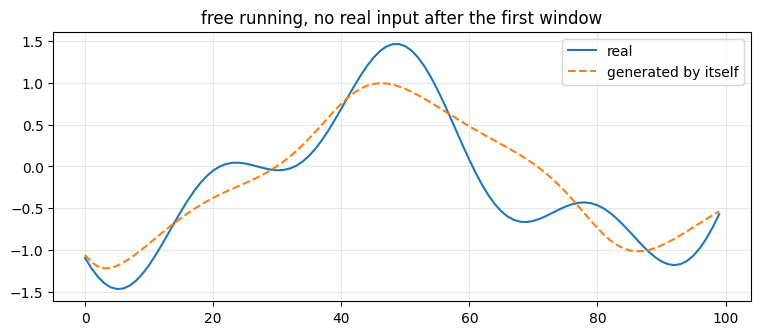

In [16]:
window = list(X_test[0])
generated = []

for i in range(100):
    p, _ = forward(np.array([window]), Wx, Wh, b, Wy, by)
    generated.append(p[0])
    window = window[1:] + [p[0]]        # slide the window using its own output

plt.figure(figsize=(9,3.5))
plt.plot(Y_test, label='real')
plt.plot(generated, '--', label='generated by itself')
plt.legend(); plt.grid(alpha=.3)
plt.title('free running, no real input after the first window')
plt.show()

### what i learned

- the forward pass is a loop of 20 tanh steps and the backward pass is the same loop going the other way
- since Wx, Wh, b are shared, their gradients get summed over all the time steps, that one line is the actual difference from a normal MLP
- gradient clipping was needed, without it the loss became nan a few times while i was trying diffrent learning rates
- the free running version drifts after a while, wich is expected because its own small errors feed back into the input